<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/N100sweepY002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running IC=vacuum_noise, N=99, gamma=0.0
Running IC=vacuum_noise, N=99, gamma=0.1
Running IC=vacuum_noise, N=99, gamma=0.3
Running IC=vacuum_noise, N=99, gamma=1.0
Running IC=vacuum_noise, N=99, gamma=3.0
Running IC=vacuum_noise, N=99, gamma=10.0
Running IC=vacuum_noise, N=100, gamma=0.0
Running IC=vacuum_noise, N=100, gamma=0.1
Running IC=vacuum_noise, N=100, gamma=0.3
Running IC=vacuum_noise, N=100, gamma=1.0
Running IC=vacuum_noise, N=100, gamma=3.0
Running IC=vacuum_noise, N=100, gamma=10.0
Running IC=vacuum_noise, N=101, gamma=0.0
Running IC=vacuum_noise, N=101, gamma=0.1
Running IC=vacuum_noise, N=101, gamma=0.3
Running IC=vacuum_noise, N=101, gamma=1.0
Running IC=vacuum_noise, N=101, gamma=3.0
Running IC=vacuum_noise, N=101, gamma=10.0
Running IC=single_bump, N=99, gamma=0.0
Running IC=single_bump, N=99, gamma=0.1
Running IC=single_bump, N=99, gamma=0.3
Running IC=single_bump, N=99, gamma=1.0
Running IC=single_bump, N=99, gamma=3.0
Running IC=single_bump, N=99, gamma=10.0
Runnin

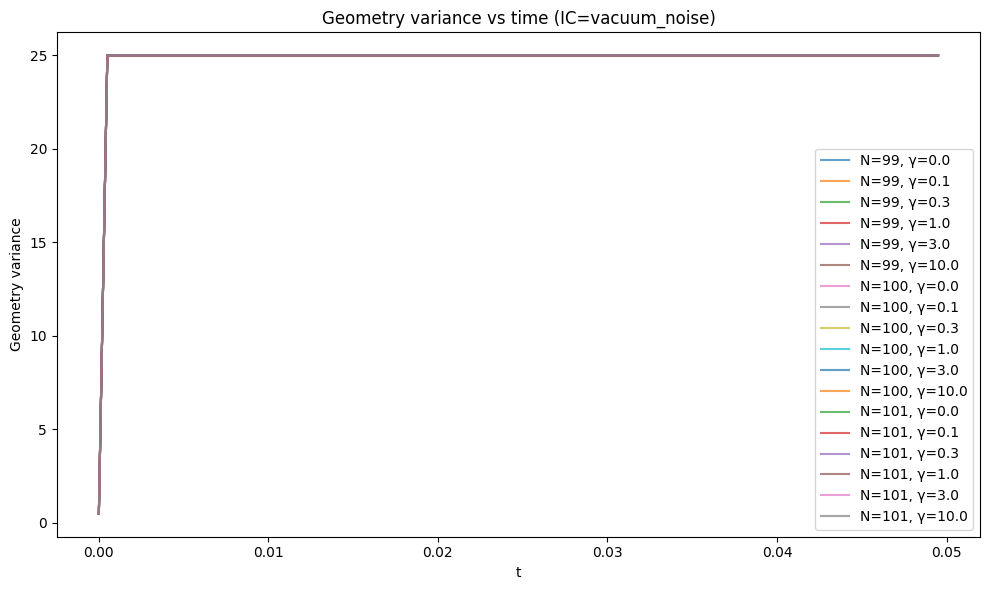

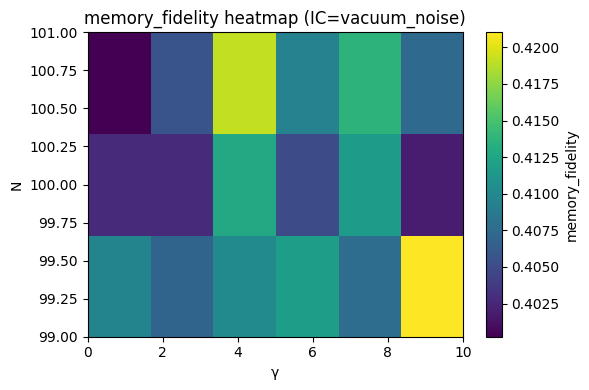

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Global parameters
# =========================

Nx, Ny = 128, 128
Lx, Ly = 1.0, 1.0
dx, dy = Lx / Nx, Ly / Ny

dt = 1e-6          # MUCH smaller timestep for stability
T_final = 0.05
n_steps = int(T_final / dt)

N_values = [99, 100, 101]
gamma_values = [0.0, 0.1, 0.3, 1.0, 3.0, 10.0]

curv_thresh = 0.05
boundary_thresh = 0.02

CLIP_S = 5.0       # clip S to avoid runaway
CLIP_GRAD = 1e4    # clip |∇S|^2


# =========================
# 2. Gradient & Laplacian
# =========================

def grad_S(S, dx, dy):
    dSdx = (np.roll(S, -1, axis=0) - np.roll(S, 1, axis=0)) / (2 * dx)
    dSdy = (np.roll(S, -1, axis=1) - np.roll(S, 1, axis=1)) / (2 * dy)
    return dSdx, dSdy

def laplacian(S, dx, dy):
    Sxx = (np.roll(S, -1, axis=0) - 2 * S + np.roll(S, 1, axis=0)) / dx**2
    Syy = (np.roll(S, -1, axis=1) - 2 * S + np.roll(S, 1, axis=1)) / dy**2
    return Sxx + Syy

def biharmonic(S, dx, dy):
    return laplacian(laplacian(S, dx, dy), dx, dy)


# =========================
# 3. Initial conditions
# =========================

def ic_vacuum_noise():
    return 1e-3 * np.random.randn(Nx, Ny)

def ic_single_bump():
    S = np.zeros((Nx, Ny))
    cx, cy = Nx // 2, Ny // 2
    radius = Nx // 10
    for i in range(Nx):
        for j in range(Ny):
            if (i - cx)**2 + (j - cy)**2 < radius**2:
                S[i, j] = 0.2
    return S

def ic_two_bumps():
    S = np.zeros((Nx, Ny))
    cx1, cy1 = Nx // 3, Ny // 2
    cx2, cy2 = 2 * Nx // 3, Ny // 2
    radius = Nx // 10
    for i in range(Nx):
        for j in range(Ny):
            if (i - cx1)**2 + (j - cy1)**2 < radius**2:
                S[i, j] = 0.2
            if (i - cx2)**2 + (j - cy2)**2 < radius**2:
                S[i, j] = -0.2
    return S

ICs = {
    "vacuum_noise": ic_vacuum_noise,
    "single_bump": ic_single_bump,
    "two_bumps": ic_two_bumps,
}


# =========================
# 4. Substrate operator F[S; N]
# =========================

def F_substrate(S, N, dx, dy):
    lap = laplacian(S, dx, dy)
    bih = biharmonic(S, dx, dy)

    cubic = 0.01 * S**3          # WEAKER cubic for stability
    alpha_N = (N - 100) * 0.01

    return 0.1 * lap - 0.1 * bih + cubic + alpha_N * S


# =========================
# 5. Metrics
# =========================

def geometry_variance(S):
    return np.var(S)

def domain_count(S, thresh):
    mask = np.abs(S) > thresh
    visited = np.zeros_like(mask, dtype=bool)
    count = 0
    for i in range(Nx):
        for j in range(Ny):
            if mask[i, j] and not visited[i, j]:
                count += 1
                stack = [(i, j)]
                while stack:
                    x, y = stack.pop()
                    if visited[x, y]:
                        continue
                    visited[x, y] = True
                    for dx_ in [-1, 0, 1]:
                        for dy_ in [-1, 0, 1]:
                            nx_ = (x + dx_) % Nx
                            ny_ = (y + dy_) % Ny
                            if mask[nx_, ny_] and not visited[nx_, ny_]:
                                stack.append((nx_, ny_))
    return count

def boundary_fraction(S, thresh):
    mask = np.abs(S) > thresh
    boundary = np.zeros_like(mask, dtype=bool)
    for i in range(Nx):
        for j in range(Ny):
            for dx_ in [-1, 0, 1]:
                for dy_ in [-1, 0, 1]:
                    ni = (i + dx_) % Nx
                    nj = (j + dy_) % Ny
                    if mask[i, j] != mask[ni, nj]:
                        boundary[i, j] = True
                        break
                if boundary[i, j]:
                    break
    return np.mean(boundary)

def memory_fidelity(S_initial, S_final):
    num = np.sum(S_initial * S_final)
    den = np.sqrt(np.sum(S_initial**2) * np.sum(S_final**2) + 1e-12)
    return num / den


# =========================
# 6. Time evolution with stabilizers
# =========================

def evolve(S0, N, gamma, dx, dy, dt, n_steps):
    S = S0.copy()
    S_initial = S0.copy()

    geom_var_series = []
    domain_series = []
    boundary_series = []

    for step in range(n_steps):

        dSdx, dSdy = grad_S(S, dx, dy)
        grad_sq = dSdx**2 + dSdy**2
        grad_sq = np.minimum(grad_sq, CLIP_GRAD)

        F = F_substrate(S, N, dx, dy)
        dSdt = F + gamma * grad_sq

        S = S + dt * dSdt
        S = np.clip(S, -CLIP_S, CLIP_S)

        if step % 500 == 0:
            geom_var_series.append(geometry_variance(S))
            domain_series.append(domain_count(S, curv_thresh))
            boundary_series.append(boundary_fraction(S, boundary_thresh))

    S_final = S.copy()
    mem_fid = memory_fidelity(S_initial, S_final)

    return {
        "S_final": S_final,
        "geom_var_series": np.array(geom_var_series),
        "domain_series": np.array(domain_series),
        "boundary_series": np.array(boundary_series),
        "memory_fidelity": mem_fid,
    }


# =========================
# 7. Sweep
# =========================

results = {}

for ic_name, ic_func in ICs.items():
    results[ic_name] = {}
    for N in N_values:
        results[ic_name][N] = {}
        for gamma in gamma_values:
            print(f"Running IC={ic_name}, N={N}, gamma={gamma}")
            S0 = ic_func()
            out = evolve(S0, N, gamma, dx, dy, dt, n_steps)
            results[ic_name][N][gamma] = out


# =========================
# 8. Diagnostics
# =========================

def plot_geom_variance_ic(ic_name):
    plt.figure(figsize=(10, 6))
    for N in N_values:
        for gamma in gamma_values:
            series = results[ic_name][N][gamma]["geom_var_series"]
            t = np.arange(len(series)) * (dt * 500)
            label = f"N={N}, γ={gamma}"
            plt.plot(t, series, label=label, alpha=0.7)
    plt.xlabel("t")
    plt.ylabel("Geometry variance")
    plt.title(f"Geometry variance vs time (IC={ic_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def stability_heatmap(ic_name, metric="memory_fidelity"):
    Ns = N_values
    gammas = gamma_values
    M = np.zeros((len(Ns), len(gammas)))
    for i, N in enumerate(Ns):
        for j, gamma in enumerate(gammas):
            M[i, j] = results[ic_name][N][gamma][metric]

    plt.figure(figsize=(6, 4))
    plt.imshow(M, aspect="auto", origin="lower",
               extent=[min(gammas), max(gammas), min(Ns), max(Ns)])
    plt.colorbar(label=metric)
    plt.xlabel("γ")
    plt.ylabel("N")
    plt.title(f"{metric} heatmap (IC={ic_name})")
    plt.tight_layout()
    plt.show()

# Example usage:
plot_geom_variance_ic("vacuum_noise")
stability_heatmap("vacuum_noise", metric="memory_fidelity")
